In [76]:
!curl -LsSf https://astral.sh/uv/install.sh | bash
!uv --version

downloading uv 0.9.7 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
uv 0.9.7


In [77]:
%cd /content/
%rm -rf CS-5137-Deep-Learning

/content


In [78]:
!git clone https://github.com/toan-ly/CS-5137-Deep-Learning
%cd CS-5137-Deep-Learning
!uv sync
%cd homework3

Cloning into 'CS-5137-Deep-Learning'...
remote: Enumerating objects: 1041, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 1041 (delta 86), reused 123 (delta 44), pack-reused 875 (from 1)
Receiving objects: 100% (1041/1041), 141.72 MiB | 46.62 MiB/s, done.
Resolving deltas: 100% (269/269), done.
/content/CS-5137-Deep-Learning
Using CPython 3.11.14
Creating virtual environment at: .venv
Resolved 82 packages in 1ms
Installed 76 packages in 249ms
 + asttokens==3.0.0
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + debugpy==1.8.17
 + decorator==5.2.1
 + executing==2.2.1
 + filelock==3.19.1
 + fonttools==4.59.2
 + fsspec==2025.9.0
 + ipykernel==6.30.1
 + ipython==9.6.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + jinja2==3.1.6
 + joblib==1.5.2
 + jupyter-client==8.6.3
 + jupyter-core==5.8.1
 + kiwisolver==1.4.9
 + markupsafe==3.0.2
 + matplotlib==3.10.6
 + matplotlib-inline==0.1.7
 + missingno==0.5.2
 + mo

In [79]:
!uv run -m src.train \
    --data_root ./data --val_ratio 0.2 \
    --num_workers 2 \
    --cache_rate 1 \
    --epochs 200 --batch_size 16 \
    --loss bce_dice --lr 3e-4 --optimizer adamw \
    --use_green_channel \
    --up_mode bilinear \
    --base_channels 64 --depth 4 \
    --early_stopping \
    --early_stopping_patience 20 \
    --save_dir checkpoints --save_plots_path results/predictions \
    --device cuda

Loading dataset: 100% 56/56 [00:00<00:00, 91.96it/s]
Loading dataset: 100% 24/24 [00:00<00:00, 87.96it/s]
Epoch 10/200 - Train Loss: 0.3398, Train Dice: 0.7130, Train IoU: 0.5566 | Val Loss: 0.4331, Val Dice: 0.5162, Val IoU: 0.3634
Epoch 20/200 - Train Loss: 0.3183, Train Dice: 0.7431, Train IoU: 0.5923 | Val Loss: 0.3242, Val Dice: 0.7467, Val IoU: 0.5971
Epoch 30/200 - Train Loss: 0.3160, Train Dice: 0.7447, Train IoU: 0.5945 | Val Loss: 0.3125, Val Dice: 0.7579, Val IoU: 0.6113
Epoch 40/200 - Train Loss: 0.3156, Train Dice: 0.7488, Train IoU: 0.5995 | Val Loss: 0.3126, Val Dice: 0.7579, Val IoU: 0.6114
Epoch 50/200 - Train Loss: 0.3165, Train Dice: 0.7458, Train IoU: 0.5958 | Val Loss: 0.3122, Val Dice: 0.7580, Val IoU: 0.6115
Epoch 60/200 - Train Loss: 0.3163, Train Dice: 0.7463, Train IoU: 0.5963 | Val Loss: 0.3125, Val Dice: 0.7579, Val IoU: 0.6114
=> Early stopping at epoch 65
Training time: 212.42s | (best val dice = 0.7582)
Model saved to checkpoints/best_model.pth


In [80]:
# %mv results/predictions results/predictions1
# %mv checkpoints checkpoints1
# %mkdir results/predictions
# %mkdir checkpoints

# !uv run -m src.train \
#     --data_root ./data --val_ratio 0.2 \
#     --num_workers 2 \
#     --cache_rate 1 \
#     --epochs 200 --batch_size 16 \
#     --loss bce_dice --lr 3e-4 --optimizer adamw \
#     --up_mode bilinear \
#     --base_channels 64 --depth 4 \
#     --early_stopping \
#     --early_stopping_patience 20 \
#     --save_dir checkpoints --save_plots_path results/predictions \
#     --device cuda

Loading dataset: 100% 56/56 [00:00<00:00, 87.29it/s]
Loading dataset: 100% 24/24 [00:00<00:00, 90.72it/s]
Epoch 10/200 - Train Loss: 0.3389, Train Dice: 0.7154, Train IoU: 0.5597 | Val Loss: 0.4604, Val Dice: 0.4821, Val IoU: 0.3336
Epoch 20/200 - Train Loss: 0.3173, Train Dice: 0.7438, Train IoU: 0.5931 | Val Loss: 0.3174, Val Dice: 0.7516, Val IoU: 0.6035
Epoch 30/200 - Train Loss: 0.3147, Train Dice: 0.7473, Train IoU: 0.5976 | Val Loss: 0.3126, Val Dice: 0.7566, Val IoU: 0.6100
Epoch 40/200 - Train Loss: 0.3145, Train Dice: 0.7504, Train IoU: 0.6015 | Val Loss: 0.3123, Val Dice: 0.7565, Val IoU: 0.6100
Epoch 50/200 - Train Loss: 0.3151, Train Dice: 0.7485, Train IoU: 0.5992 | Val Loss: 0.3119, Val Dice: 0.7568, Val IoU: 0.6103
Epoch 60/200 - Train Loss: 0.3149, Train Dice: 0.7484, Train IoU: 0.5989 | Val Loss: 0.3125, Val Dice: 0.7567, Val IoU: 0.6101
=> Early stopping at epoch 65
Training time: 211.89s | (best val dice = 0.7569)
Model saved to checkpoints/best_model.pth


In [81]:
import pandas as pd
import matplotlib.pyplot as plt

In [82]:
history_df = pd.read_csv('checkpoints/training_history.csv')
history_df.head()

,Unnamed: 0,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,epoch
0,0,0.626819,0.342734,0.212634,0.697787,0.218721,0.122949,1
1,1,0.511752,0.515326,0.354014,0.685893,0.216176,0.121385,2
2,2,0.465078,0.569075,0.406010,0.667955,0.000042,0.000021,3
3,3,0.426440,0.622075,0.456792,0.640154,0.000000,0.000000,4
4,4,0.395856,0.672145,0.509035,0.615895,0.000011,0.000006,5


In [83]:
# history_df2 = pd.read_csv('checkpoints1/training_history.csv')
# history_df2.head()

,Unnamed: 0,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,epoch
0,0,0.625431,0.346323,0.215426,0.697748,0.218721,0.122949,1
1,1,0.515144,0.492274,0.334098,0.684752,0.157055,0.086328,2
2,2,0.462174,0.570659,0.408873,0.661437,0.000000,0.000000,3
3,3,0.421532,0.631795,0.465663,0.643307,0.000618,0.000310,4
4,4,0.398681,0.658021,0.493532,0.665508,0.159123,0.088345,5


In [84]:
def plot_loss(loss_df, save_dir):
    """
    Plots training and validation loss, accuracy, and F1 score
    over epochs for different models and learning rates.
    """

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].plot(loss_df['epoch'], loss_df['train_loss'], label='train_loss')
    axs[0].plot(loss_df['epoch'], loss_df['val_loss'], label='val_loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training and Validation Loss')
    axs[0].legend()

    axs[1].plot(loss_df['epoch'], loss_df['train_dice'], label='train_dice')
    axs[1].plot(loss_df['epoch'], loss_df['val_dice'], label='val_dice')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Dice')
    axs[1].set_title('Training and Validation Dice')
    axs[1].legend()

    axs[2].plot(loss_df['epoch'], loss_df['train_iou'], label='train_iou')
    axs[2].plot(loss_df['epoch'], loss_df['val_iou'], label='val_iou')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('IoU')
    axs[2].set_title('Training and Validation IoU')
    axs[2].legend()

    plt.tight_layout()
    plt.show()


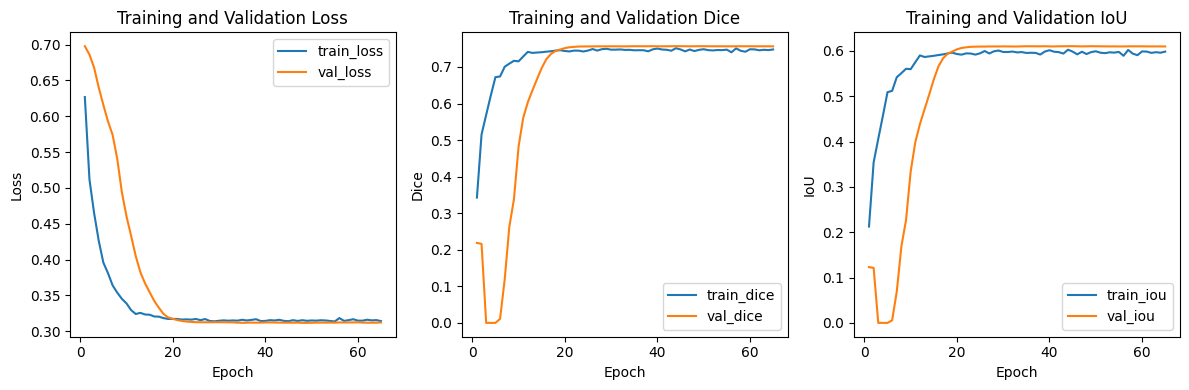

In [85]:
plot_loss(history_df, 'checkpoints')

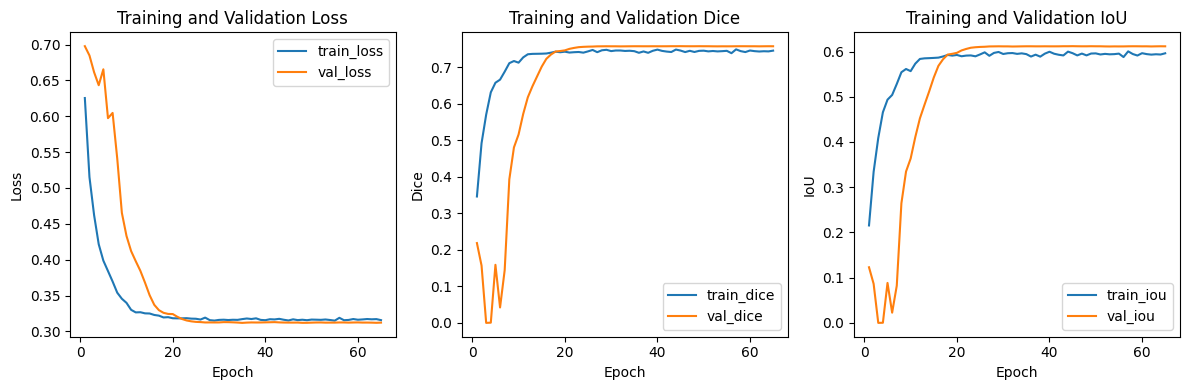

In [86]:
# plot_loss(history_df2, 'checkpoints1')